In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,auc

In [ ]:
df = pd.read_excel('/content/student_performance_dataset.xlsx', header=1)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('pass', axis=1)
y = df['pass']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("Predictions:", predictions)
print("Accuracy:", accuracy)

Predictions: [1 0 0]
Accuracy: 1.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

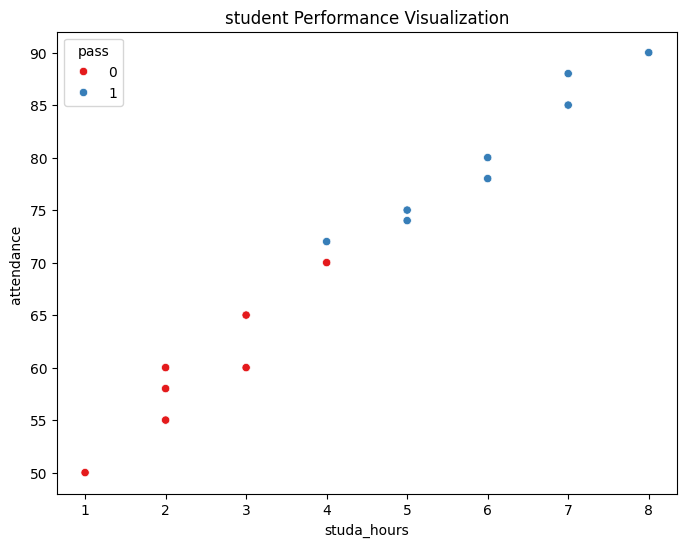

In [ ]:
# Take sample to avoid heavy plotting
# Given the small size of the DataFrame (15 rows), sampling is not necessary.
# Using the full DataFrame for plotting.

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df, # Changed from sample_df to df
    x='study_hours',
    y='attendance',
    hue='pass',
    palette='Set1',
    alpha=1 # Corrected alpha value to be within 0-1 range
)

plt.title("student Performance Visualization")
plt.xlabel("studa_hours")
plt.ylabel("attendance ")
plt.legend(title="pass")
plt.show()

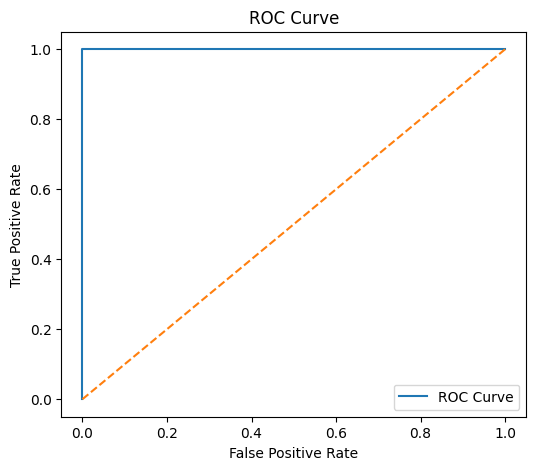

AUC Score: 1.0


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

# Convert y_test (boolean) to numerical (0 or 1) for roc_curve
y_test_numeric = y_test.astype(int)

fpr, tpr, thresholds = roc_curve(y_test_numeric, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

print("AUC Score:", roc_auc_score(y_test_numeric, y_prob))

In [ ]:
Thank You